In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
old = pd.read_csv('mutation_neutralization_effects.csv')
old

,Mutation,Mean,Std,N
0,S704L,0.615408,0.263516,320.0
1,K417V,0.587704,0.130104,184.0
2,T478K,0.579455,0.153464,1594.0
3,S155R,0.561146,0.111577,230.0
4,V213G,0.542485,0.664872,1286.0
...,...,...,...,...
105,K444T,-0.698179,0.506259,69.0
106,Q493S,-0.747304,0.268966,23.0
107,F486P,-0.821676,0.532858,23.0
108,G446S,-0.917341,0.834617,906.0


In [5]:
new = pd.read_csv('results/mutation_neutralization_effects.csv')
new

,Mutation,Mean,Std,N
0,K417V,0.551918,0.126604,184.0
1,T478K,0.500255,0.144470,1594.0
2,S155R,0.441260,0.109852,230.0
3,G339H,0.216259,0.274757,515.0
4,S704L,0.153198,0.188786,320.0
...,...,...,...,...
105,G446S,-0.446591,0.419496,906.0
106,L452R,-0.486195,0.082643,690.0
107,K444T,-0.626851,0.260245,69.0
108,F486P,-0.731698,0.336534,23.0


0      704
1      417
2      478
3      155
4      213
      ... 
105    444
106    493
107    486
108    446
109    501
Name: Mutation, Length: 110, dtype: int64

In [46]:
df

,Mutation,Mean Effect - Normal,Std Effect - Normal,N Effect - Normal,Mean Effect - Laplace,Std Effect - Laplace,N Effect - Laplace,Position,Region
0,S704L,0.615408,0.263516,320.0,0.153198,0.188786,320.0,704,
1,K417V,0.587704,0.130104,184.0,0.551918,0.126604,184.0,417,RBD
2,T478K,0.579455,0.153464,1594.0,0.500255,0.144470,1594.0,478,RBD
3,S155R,0.561146,0.111577,230.0,0.441260,0.109852,230.0,155,
4,V213G,0.542485,0.664872,1286.0,0.122663,0.228735,1286.0,213,
...,...,...,...,...,...,...,...,...,...
105,K444T,-0.698179,0.506259,69.0,-0.626851,0.260245,69.0,444,RBD
106,Q493S,-0.747304,0.268966,23.0,-0.284921,0.209485,23.0,493,RBD
107,F486P,-0.821676,0.532858,23.0,-0.731698,0.336534,23.0,486,RBD
108,G446S,-0.917341,0.834617,906.0,-0.446591,0.419496,906.0,446,RBD


In [45]:
df = pd.merge(old, new, on='Mutation', suffixes=(' Effect - Normal', ' Effect - Laplace'))
df['Position'] = df['Mutation'].apply(lambda c: int(''.join(filter(str.isdigit, c))))
df['Region'] = ''; df['Region'][(df['Position']>333) & (df['Position']<527)]='RBD'

C:\Users\blk18\AppData\Local\Temp\ipykernel_20248\3672381081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Region'] = ''; df['Region'][(df['Position']>333) & (df['Position']<527)]='RBD'


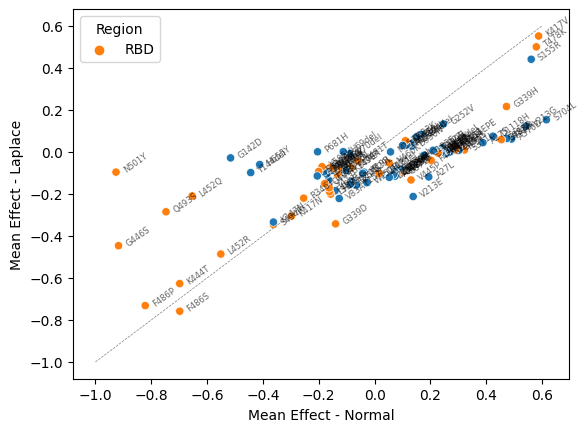

In [47]:
fig, ax = plt.subplots()

sns.scatterplot(x='Mean Effect - Normal',
                y='Mean Effect - Laplace',
                hue='Region',
                data=df,
                ax=ax)

for line in range(len(df)):
     ax.text(df['Mean Effect - Normal'][line]+0.02, df['Mean Effect - Laplace'][line], df['Mutation'][line], horizontalalignment='left', size=6, alpha=0.6, color='black', rotation=36)

ax.plot(np.linspace(-1, 0.6, 10), np.linspace(-1, 0.6, 10), linestyle='--', linewidth=0.5, color='gray');